In [ ]:
!apt-get update
!apt-get install -y tesseract-ocr
!pip install opencv-python pytesseract matplotlib

Grayscale Image:


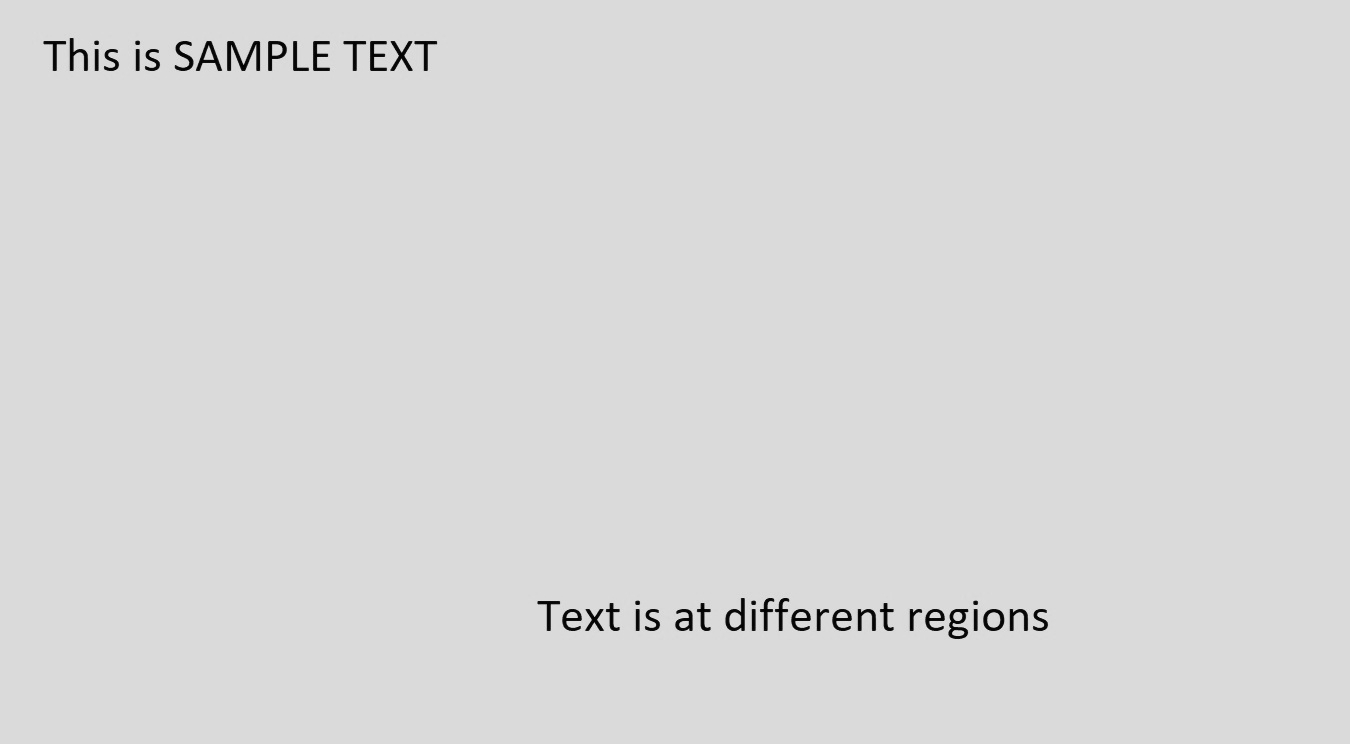

-----


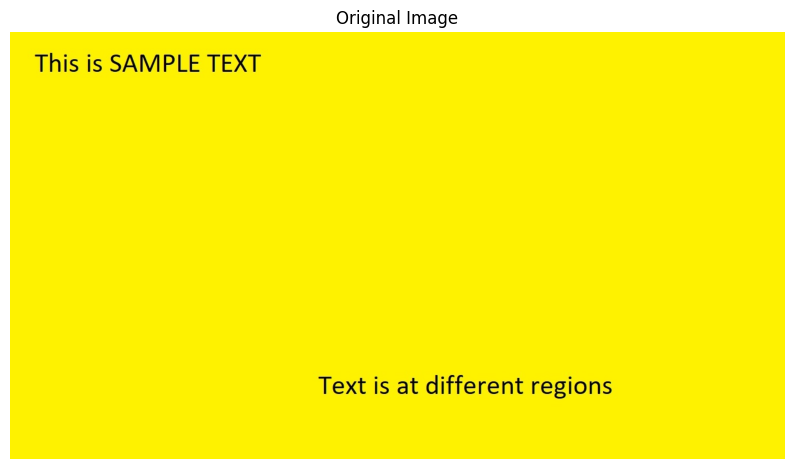

Extracted Text:

This is SAMPLE TEXT

Text is at different regions



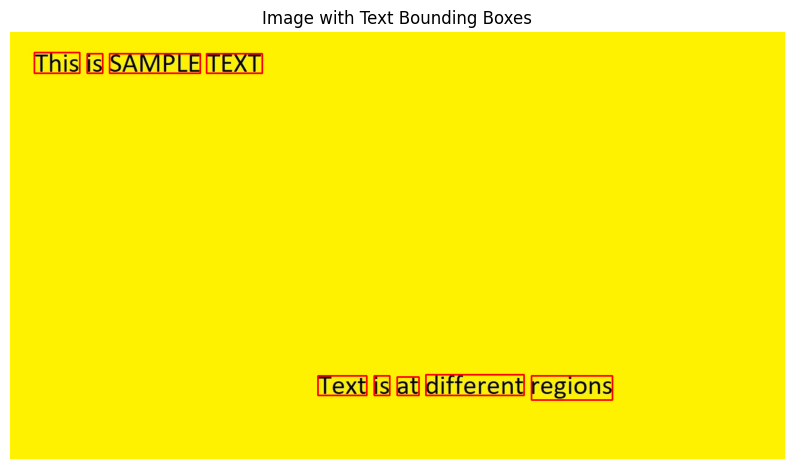

In [12]:
# ==============================
# STEP 1: Import Required Packages
# ==============================
import cv2
import pytesseract
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# ==============================
# STEP 2: Upload and Load Image
# ==============================
            # This code get from system file 👇
# from google.colab import files

# uploaded = files.upload()  # Upload any image containing text
# image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)
image = cv2.imread("/content/Original-Image.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ==============================
# STEP 3: Convert Image to Grayscale
# ==============================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Grayscale Image:")
cv2_imshow(gray)
print("-----")

# ==============================
# STEP 4: Display Original Image
# ==============================
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


# ==============================
# STEP 5: Extract Text from Image
# ==============================
extracted_text = pytesseract.image_to_string(image_rgb)

print("Extracted Text:\n")
print(extracted_text)

# ==============================
# STEP 6: Draw Bounding Boxes Around Detected Text
# ==============================
data = pytesseract.image_to_data(image_rgb, output_type=pytesseract.Output.DICT)

n_boxes = len(data['text'])
for i in range(n_boxes):
    if int(data['conf'][i]) > 0:  # Filter weak detections
        x = data['left'][i]
        y = data['top'][i]
        w = data['width'][i]
        h = data['height'][i]
        cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

# ==============================
# STEP 7: Show Image with Bounding Boxes
# ==============================
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Image with Text Bounding Boxes")
plt.axis("off")
plt.show()
